## Lecture 1b - Outputs of FFT

Here we will just relate ourselves a bit to the output of FFTs

In [1]:
import numpy as np
import matplotlib.pyplot as plt

[0.   0.25 0.5  0.75]
[1. 1. 0. 1.]
[ 0.    0.25  0.   -0.25]
[ 0.  1. -2. -1.]


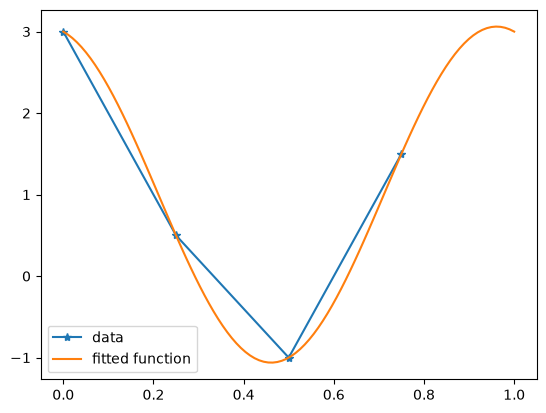

In [2]:
N = 4
L = 1;
x = np.arange(N)*L/N; print(x)
y = 1 + 2*np.cos(2*np.pi*x) - 1/2*np.sin(2*np.pi*x)

ft = np.fft.fft(y); 
print(np.round(ft.real/N, 1))
print(np.round(ft.imag/N, 2))
print(np.fft.fftfreq(N,d=L/N))
A_0 = ft.real[0]/N
A_1 = 2*ft.real[1]/N
B_1 = -2*ft.imag[1]/N


xl = np.linspace(0,1,100);
S_n = A_0 + A_1*np.cos(2*np.pi*xl) + B_1*np.sin(2*np.pi*xl)
plt.plot(x,y,'-*',label='data')
plt.plot(xl,S_n,label='fitted function')
plt.legend()
plt.show()

## Using fft for differentiation

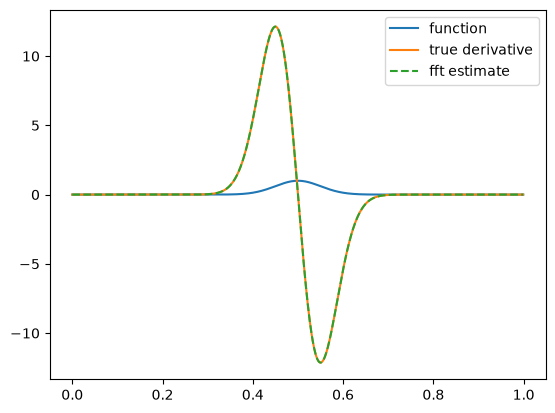

In [3]:
def spectral_diff(f, L):
    k_L = np.fft.fftfreq(f.size, d=L/f.size)
    q = 2j*np.pi*k_L
    return np.real(np.fft.ifft(q*np.fft.fft(f)))

### We have a gaussian with std = 0.05 on x = [0,1]
L, sigma = 1.0, 0.05
N = 1000
x = np.arange(N)*L/N

f      = np.exp(-(x-0.5)**2/(2*sigma**2))     ### the function
df_true = -(x-0.5)/sigma**2 * f                ### The true derivative

### Find derivative from fft:
f_spec = spectral_diff(f, L)


plt.plot(x,f,label = 'function')
plt.plot(x,df_true,label = 'true derivative')
plt.plot(x,f_spec,'--',label = 'fft estimate')
plt.legend()
plt.show()



## So it looks correct - lets compare to the difference schemes

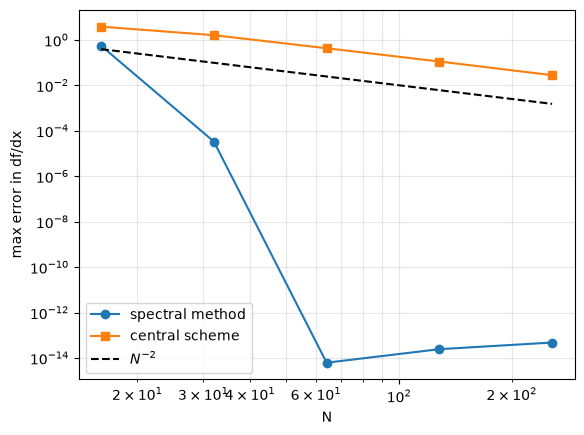

In [4]:
################## 
### We try 6 different values of N - i.e higher N smaller dx

Ns = [16, 32, 64, 128, 256]

### Lets compute the errors for spectral method and finite difference
err_spec = [];
err_fd = []

for N in Ns:
    x = np.arange(N)*L/N
    dx = L/N
    
    f      = np.exp(-(x-0.5)**2/(2*sigma**2))     ### the function
    df_true = -(x-0.5)/sigma**2 * f     

    df_spec = spectral_diff(f, L)
    df_fd   = (np.roll(f,-1) - np.roll(f,1))/(2*dx) ### central scheme
    
    ### Insert the maximal error for each N
    err_spec.append(np.max(np.abs(df_spec - df_true)))
    err_fd.append(  np.max(np.abs(df_fd   - df_true)))

plt.loglog(Ns, err_spec, 'o-', label='spectral method')
plt.loglog(Ns, err_fd,   's-', label='central scheme')
plt.loglog(Ns, [1e2/N**2 for N in Ns], 'k--', label='$N^{-2}$')
plt.xlabel('N'); plt.ylabel('max error in df/dx')
plt.legend(); plt.grid(True, which='both', alpha=.3)

## Lets do the second order derivative

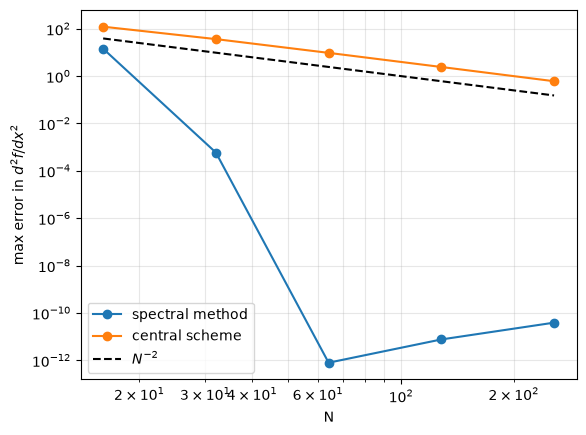

In [5]:
def spectral_diff(f, L, order=1):
    q = 2j*np.pi*np.fft.fftfreq(f.size, d=L/f.size)
    F = np.fft.fft(f)
    return np.real(np.fft.ifft(q**order * F))


Ns = [16, 32, 64, 128, 256]
err_spec = []
err_fd   = []
for N in Ns:
    x  = np.arange(N)*L/N
    dx = L/N

    f       = np.exp(-(x-0.5)**2/(2*sigma**2))
    d2_true = ((x-0.5)**2/sigma**4 - 1/sigma**2) * f
    d2_spec = spectral_diff(f, L,order = 2)
    d2_fd   = (np.roll(f,-1) - 2*f + np.roll(f,1))/dx**2   ### central scheme

    err_spec.append(np.max(np.abs(d2_spec - d2_true)))
    err_fd.append(  np.max(np.abs(d2_fd   - d2_true)))

plt.loglog(Ns, err_spec, 'o-', label='spectral method')
plt.loglog(Ns, err_fd,   'o-', label='central scheme')
plt.loglog(Ns, [1e4/N**2 for N in Ns], 'k--', label='$N^{-2}$')
plt.xlabel('N'); plt.ylabel('max error in $d^2f/dx^2$')
plt.legend(); plt.grid(True, which='both', alpha=.3)